# Getting Started

In this analysis, we will perform an Exploratory Data Analysis (EDA) on a dataset containing information about K-pop idols. Our dataset includes information such as stage name, full name, date of birth, group, debut date, company, country, height, weight, birthplace, and gender. The primary goal of this EDA is to uncover trends, patterns, and relationships within the data, which can provide valuable insights into the K-pop industry.

![](https://i0.wp.com/www.korseries.com/wp-content/uploads/2022/03/sehun-exo-cover.jpg?w=2000&ssl=1)

# Data Description 

Here is a description of each column in the given dataset:

1. Stage Name: The name used by the K-pop idol when performing on stage or in public appearances.
2. Full Name: The real name of the K-pop idol, including first and last names.
3. Date of Birth: The idol's birth date in the format YYYY-MM-DD.
4. Group: The name of the K-pop group the idol is currently a member of.
5. Debut: The date when the idol or their group made their official debut in the format YYYY-MM-DD.
6. Company: The entertainment agency or company that manages the idol's career.
7. Country: The idol's country of origin or nationality.
8. Height: The idol's height in centimeters.
9. Weight: The idol's weight in kilograms.
10. Birthplace: The city or region where the idol was born.
11. Other Group: Any other group(s) that the idol is currently a member of, besides their primary group.
12. Former Group: Any group(s) the idol was a member of in the past but is no longer associated with.
13. Gender: The idol's gender, represented as 'M' for male and 'F' for female.
14. Age: The idol's current age in years, calculated based on their date of birth.
15. Debut Age: The age of the idol when they made their debut, calculated based on their date of birth and debut date.
16. Zodiac: The idol's zodiac sign, based on their date of birth.

**Import Neccessary Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')
from datetime import datetime

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
data = pd.read_csv("/kaggle/input/all-kpop-idols/kpopidolsv3.csv")

# 1. Data Cleansing and Data Prep

In [3]:
#check missing ratio
data_na = (data.isnull().sum() / len(data)) * 100
data_na = data_na.drop(data_na[data_na == 0].index).sort_values(ascending=False)[:30]
missing_data = pd.DataFrame({'Missing Ratio' :data_na})
missing_data.head(20)

,Missing Ratio
Second Country,96.512936
Other Group,92.125984
Former Group,85.151856
Weight,68.166479
Birthplace,53.093363
Height,52.980877
Group,8.211474
Debut,8.211474
Company,8.211474
Korean Name,0.562430


In [4]:
# Handle duplicates
duplicate_rows_data = data[data.duplicated()]
print("number of duplicate rows: ", duplicate_rows_data.shape)

number of duplicate rows:  (0, 16)


In [5]:
# Loop through each column and count the number of distinct values
for column in data.columns:
    num_distinct_values = len(data[column].unique())
    print(f"{column}: {num_distinct_values} distinct values")

Stage Name: 1469 distinct values
Full Name: 1676 distinct values
Korean Name: 1655 distinct values
K Stage Name: 1368 distinct values
Date of Birth: 1554 distinct values
Group: 288 distinct values
Debut: 267 distinct values
Company: 181 distinct values
Country: 20 distinct values
Second Country: 17 distinct values
Height: 39 distinct values
Weight: 47 distinct values
Birthplace: 162 distinct values
Other Group: 63 distinct values
Former Group: 129 distinct values
Gender: 2 distinct values


In [6]:
data['Debut'] = data['Debut'].replace('0/01/1900', pd.NA)

In [7]:
data['Date of Birth'] = pd.to_datetime(data['Date of Birth'], format='%d/%m/%Y')
data['Debut'] = pd.to_datetime(data['Debut'], format='%d/%m/%Y')

data['age'] = (datetime.now() - data['Date of Birth']).astype('<m8[Y]')
data['Debut Age'] = (data['Debut'] - data['Date of Birth']).astype('<m8[Y]')

In [8]:
# Define a function to create zodiac sign
def get_zodiac_sign(date):
    if (date.month == 1 and date.day >= 20) or (date.month == 2 and date.day <= 18):
        return 'Aquarius'
    elif (date.month == 2 and date.day >= 19) or (date.month == 3 and date.day <= 20):
        return 'Pisces'
    elif (date.month == 3 and date.day >= 21) or (date.month == 4 and date.day <= 19):
        return 'Aries'
    elif (date.month == 4 and date.day >= 20) or (date.month == 5 and date.day <= 20):
        return 'Taurus'
    elif (date.month == 5 and date.day >= 21) or (date.month == 6 and date.day <= 20):
        return 'Gemini'
    elif (date.month == 6 and date.day >= 21) or (date.month == 7 and date.day <= 22):
        return 'Cancer'
    elif (date.month == 7 and date.day >= 23) or (date.month == 8 and date.day <= 22):
        return 'Leo'
    elif (date.month == 8 and date.day >= 23) or (date.month == 9 and date.day <= 22):
        return 'Virgo'
    elif (date.month == 9 and date.day >= 23) or (date.month == 10 and date.day <= 22):
        return 'Libra'
    elif (date.month == 10 and date.day >= 23) or (date.month == 11 and date.day <= 21):
        return 'Scorpio'
    elif (date.month == 11 and date.day >= 22) or (date.month == 12 and date.day <= 21):
        return 'Sagittarius'
    else:
        return 'Capricorn'

# Apply the function to 'Date of Birth' column to get 'Zodiac' column
data['Zodiac'] = data['Date of Birth'].apply(get_zodiac_sign)

In [9]:
data = data.drop(['Korean Name','K Stage Name','Second Country'], axis=1)

In [10]:
data.head()

,Stage Name,Full Name,Date of Birth,Group,Debut,Company,Country,Height,Weight,Birthplace,Other Group,Former Group,Gender,age,Debut Age,Zodiac
0,2Soul,Kim Younghoon,1997-09-10,7 O'clock,2014-08-26,Jungle,South Korea,172.0,55.0,NaN,NaN,NaN,M,25.0,16.0,Virgo
1,A.M,Seong Hyunwoo,1996-12-31,Limitless,2019-07-09,ONO,South Korea,181.0,62.0,NaN,NaN,NaN,M,26.0,22.0,Capricorn
2,Ace,Jang Wooyoung,1992-08-28,VAV,2015-10-31,A team,South Korea,177.0,63.0,NaN,NaN,NaN,M,30.0,23.0,Virgo
3,Aeji,Kwon Aeji,1999-10-25,Hash Tag,2017-10-11,LUK,South Korea,163.0,NaN,Daegu,NaN,NaN,F,23.0,17.0,Scorpio
4,AhIn,Lee Ahin,1999-09-27,MOMOLAND,2016-11-09,Double Kick,South Korea,160.0,44.0,Wonju,NaN,NaN,F,23.0,17.0,Libra


# 2. Does Height Matter ?

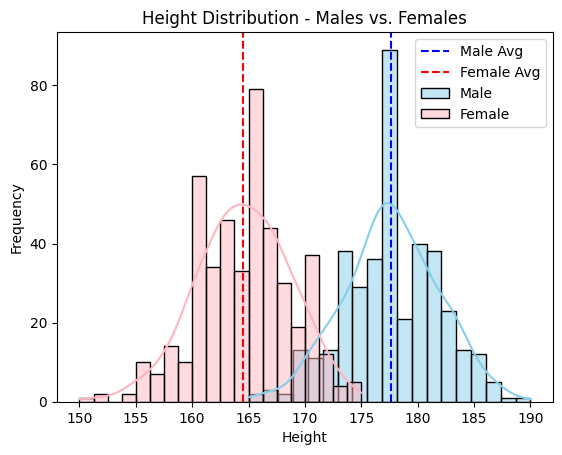

In [11]:
# Separate data for males and females
male_data = data[data['Gender'] == 'M']
female_data = data[data['Gender'] == 'F']

# Set color palette
sns.set_palette('pastel')

# Plotting distribution with average for males and females
sns.histplot(data=male_data, x='Height', kde=True, color='skyblue', label='Male')
sns.histplot(data=female_data, x='Height', kde=True, color='lightpink', label='Female')
plt.axvline(x=male_data['Height'].mean(), color='blue', linestyle='dashed', linewidth=1.5, label='Male Avg')
plt.axvline(x=female_data['Height'].mean(), color='red', linestyle='dashed', linewidth=1.5, label='Female Avg')
plt.xlabel('Height')
plt.ylabel('Frequency')
plt.title('Height Distribution - Males vs. Females')
plt.legend()
plt.show()

 # 3. What body type is ideal for being an K-POP Idol?

![](https://mpics.mgronline.com/pics/Images/561000010883002.JPEG)

![](https://i.ytimg.com/vi/4LfANanF0Dg/maxresdefault.jpg)

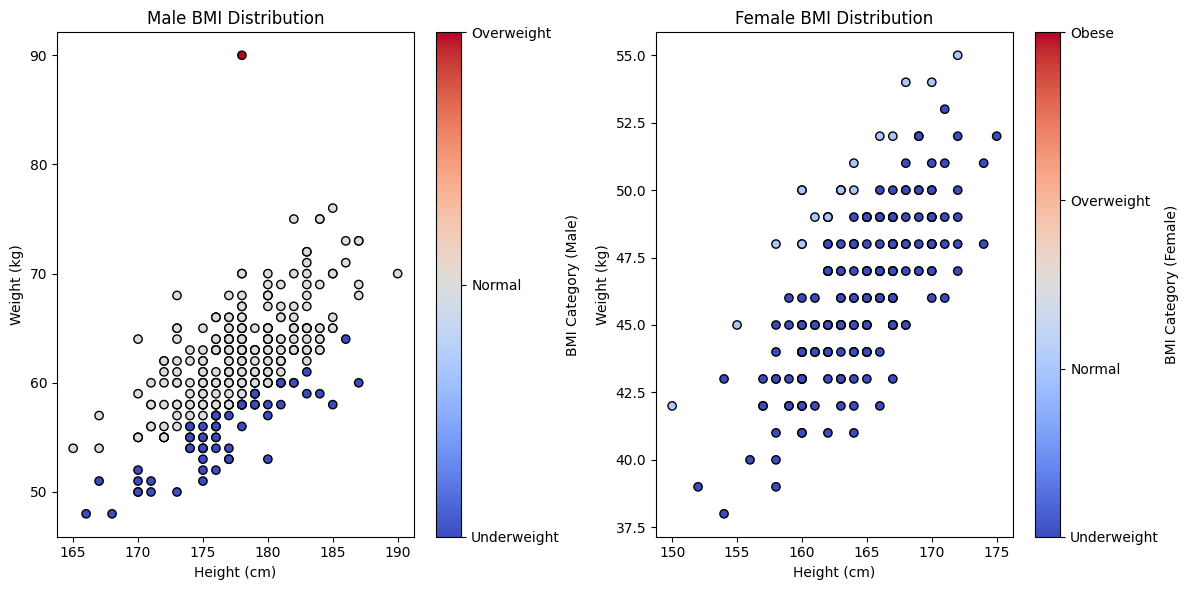

In [12]:
# Filter rows where both 'Height' and 'Weight' are not null
filtered_data = data.dropna(subset=['Height', 'Weight'])

# Calculate BMI
filtered_data['BMI'] = filtered_data['Weight'] / ((filtered_data['Height'] / 100) ** 2)

# Define BMI categories and corresponding colors
bmi_categories = ['Underweight', 'Normal', 'Overweight', 'Obese']
bmi_category_colors = ['blue', 'green', 'orange', 'red']
bmi_category_ranges = [0, 18.5, 25, 30, np.inf]

# Determine BMI category for each individual
filtered_data['BMI Category'] = pd.cut(filtered_data['BMI'], bins=bmi_category_ranges, labels=bmi_categories)

# Convert BMI categories to numeric codes
filtered_data['BMI Category Code'] = pd.Categorical(filtered_data['BMI Category'], categories=bmi_categories).codes

# Separate data by gender
male_data = filtered_data[filtered_data['Gender'] == 'M']
female_data = filtered_data[filtered_data['Gender'] == 'F']

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Male BMI graph
male_scatter = ax1.scatter(male_data['Height'], male_data['Weight'], c=male_data['BMI Category Code'], cmap='coolwarm', edgecolors='black')
ax1.set_xlabel('Height (cm)')
ax1.set_ylabel('Weight (kg)')
ax1.set_title('Male BMI Distribution')

# Female BMI graph
female_scatter = ax2.scatter(female_data['Height'], female_data['Weight'], c=female_data['BMI Category Code'], cmap='coolwarm', edgecolors='black', vmin=0, vmax=len(bmi_categories)-1)
ax2.set_xlabel('Height (cm)')
ax2.set_ylabel('Weight (kg)')
ax2.set_title('Female BMI Distribution')

# Colorbar for male graph
cbar_male = plt.colorbar(male_scatter, ax=ax1, ticks=np.arange(len(bmi_categories)))
cbar_male.set_label('BMI Category (Male)')
cbar_male.set_ticklabels(bmi_categories)

# Colorbar for female graph
cbar_female = plt.colorbar(female_scatter, ax=ax2, ticks=np.arange(len(bmi_categories)))
cbar_female.set_label('BMI Category (Female)')
cbar_female.set_ticklabels(bmi_categories)

plt.tight_layout()
plt.show()

**The result appears like the majority of K-pop stars are underweight**

# 4. Age At The Time Of Their Debut

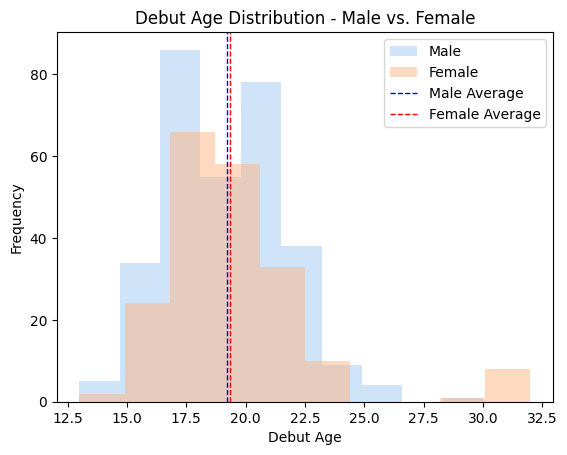

In [13]:
# Dealing with wring value
male_data = male_data[male_data['Debut Age'] >= 10]
female_data = female_data[female_data['Debut Age'] >= 10]

# Calculate average debut age for males and females
male_avg = male_data['Debut Age'].mean()
female_avg = female_data['Debut Age'].mean()

# Plotting the 'Debut Age' for males and females
plt.hist(male_data['Debut Age'].dropna(), bins=10, alpha=0.5, label='Male')
plt.hist(female_data['Debut Age'].dropna(), bins=10, alpha=0.5, label='Female')
plt.axvline(x=male_avg, color='blue', linestyle='dashed', linewidth=1, label='Male Average')
plt.axvline(x=female_avg, color='red', linestyle='dashed', linewidth=1, label='Female Average')
plt.xlabel('Debut Age')
plt.ylabel('Frequency')
plt.title('Debut Age Distribution - Male vs. Female')
plt.legend()
plt.show()

# 5. Age Distribution

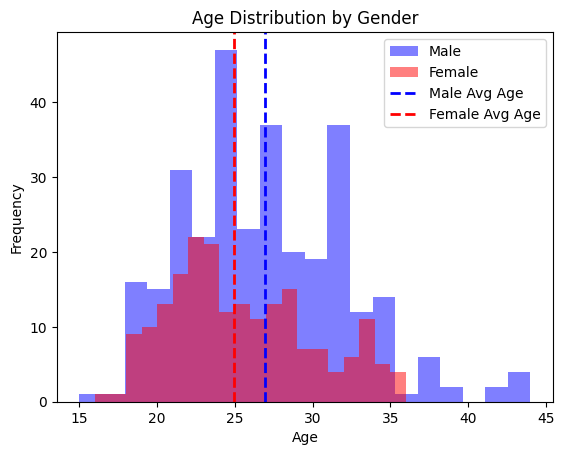

In [14]:
# Calculate average age for males and females
male_avg_age = male_data['age'].mean()
female_avg_age = female_data['age'].mean()

# Plot age distribution for males
plt.hist(male_data['age'], bins=20, color='blue', alpha=0.5, label='Male')

# Plot age distribution for females
plt.hist(female_data['age'], bins=20, color='red', alpha=0.5, label='Female')

# Add average lines for males and females
plt.axvline(male_avg_age, color='blue', linestyle='--', linewidth=2, label='Male Avg Age')
plt.axvline(female_avg_age, color='red', linestyle='--', linewidth=2, label='Female Avg Age')

# Set plot labels and title
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution by Gender')

# Add a legend
plt.legend()

# Display the plot
plt.show()

# 6. What nation are K-POP idols from?

In [15]:
df =data.copy()
# Count the number of K-pop idols by birthplace (country)
birthplace_counts = df['Country'].value_counts().reset_index()
birthplace_counts.columns = ['Country', 'Count']

# Create a choropleth map using Plotly with a log scale for color
fig = px.choropleth(birthplace_counts,
                    locations='Country',
                    locationmode='country names',
                    color=np.log10(birthplace_counts['Count']),
                    hover_name='Country',
                    custom_data=[birthplace_counts['Count']],
                    color_continuous_scale=px.colors.sequential.Plasma,
                    title='K-pop Idols by Birthplace (Country) - Log Scale',
                    labels={'color': 'Log10(Number of K-pop Idols)'},
                    projection='natural earth')

# Create a custom hover template
hovertemplate = "<b>%{hovertext}</b><br>Number of K-pop Idols: %{customdata[0]}<br>Log10(Number of K-pop Idols): %{z:.2f}<extra></extra>"

# Update the hover template using the update_traces() method
fig.update_traces(hovertemplate=hovertemplate)

fig.show()

# 7. Top 10 Birthplaces

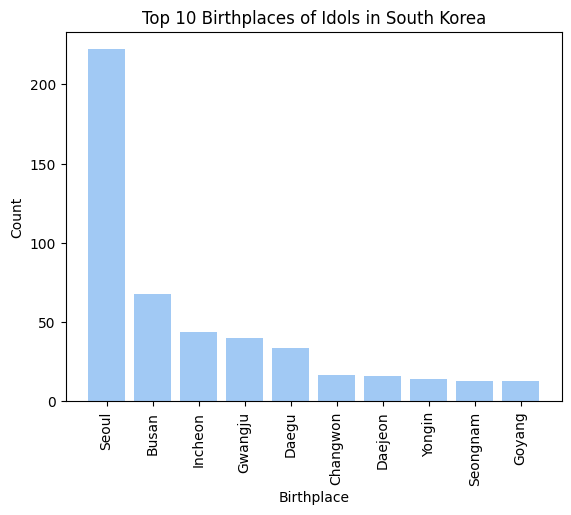

In [16]:
# Filter the data for rows where the 'Country' column is 'South Korea'
south_korea_data = data[data['Country'] == 'South Korea']

# Count the occurrences of each birthplace and get the top 10
birthplace_counts = south_korea_data['Birthplace'].value_counts().head(10)

# Plot the top 10 birthplace counts
plt.bar(birthplace_counts.index, birthplace_counts.values)
plt.xlabel('Birthplace')
plt.ylabel('Count')
plt.title('Top 10 Birthplaces of Idols in South Korea')
plt.xticks(rotation=90)
plt.show()

# 8. How frequently do idol debuts?

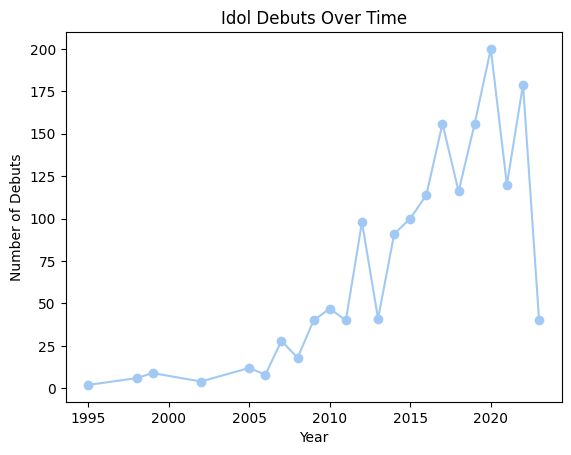

In [17]:
# Convert the 'Debut' column to datetime
data['Debut'] = pd.to_datetime(data['Debut'])

# Group by year and count the number of debuts
debut_counts = data['Debut'].dt.year.value_counts().sort_index()

# Plot the idol debuts over time
plt.plot(debut_counts.index, debut_counts.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Number of Debuts')
plt.title('Idol Debuts Over Time')
plt.show()

# 9. Zodiac Sign

![](https://hips.hearstapps.com/hmg-prod/images/dog-astrology-1641470968.jpg)

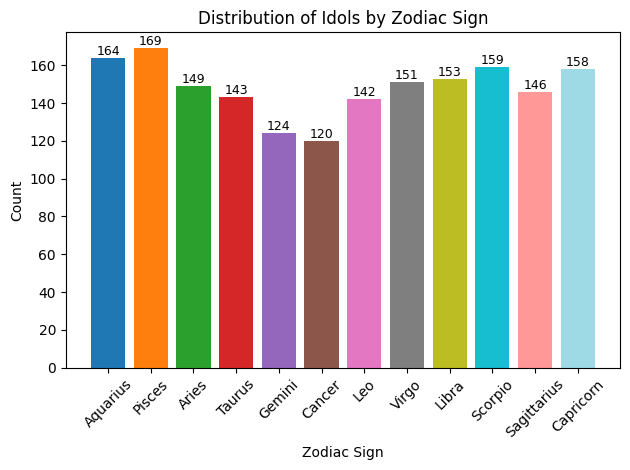

In [18]:
# Define colors for each zodiac sign
zodiac_colors = {
    'Aquarius': '#1f77b4',
    'Pisces': '#ff7f0e',
    'Aries': '#2ca02c',
    'Taurus': '#d62728',
    'Gemini': '#9467bd',
    'Cancer': '#8c564b',
    'Leo': '#e377c2',
    'Virgo': '#7f7f7f',
    'Libra': '#bcbd22',
    'Scorpio': '#17becf',
    'Sagittarius': '#ff9896',
    'Capricorn': '#9edae5'
}

# Count the occurrences of each zodiac sign
zodiac_counts = data['Zodiac'].value_counts()

# Sort the zodiac counts by the zodiac sign order
sorted_zodiac_counts = zodiac_counts.loc[list(zodiac_colors.keys())]

# Plot the zodiac sign distribution with correlated colors
fig, ax = plt.subplots()
bars = ax.bar(sorted_zodiac_counts.index, sorted_zodiac_counts.values, color=[zodiac_colors[zodiac] for zodiac in sorted_zodiac_counts.index])

# Add labels and percentages above each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:,}', ha='center', va='bottom', fontsize=9)

# Customize the plot
plt.xlabel('Zodiac Sign')
plt.ylabel('Count')
plt.title('Distribution of Idols by Zodiac Sign')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

> **If you discovered this notebook to be useful or enjoyable, I'd greatly appreciate any upvotes! Your support motivates me to regularly update and improve it. :-)**